<a href="https://colab.research.google.com/github/DanielBilxes/tarea6-clasificacion-ml/blob/main/Experimento_Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 6: Clasificación - Teaching Assistant Evaluation
**Integrantes:** Ignacio Essus, Adolfo Gayoso, Marcelo Rebolledo, Daniel Sepúlveda

## 1. Definición del Problema y Experimento

**Definición del problema:**
Se trata de un problema de clasificación multiclase. El objetivo es predecir el desempeño de un ayudante de cátedra (TA) catalogado en tres niveles: 1 (Bajo), 2 (Medio) o 3 (Alto), basándose en atributos como el tamaño de la clase, el semestre, el instructor, el curso y si el ayudante es hablante nativo de inglés.

**Definición del experimento:**
* **Dataset:** Teaching Assistant Evaluation (UCI).
* **Entrenamiento:** Hold-out estratificado (80% Train, 20% Test) debido al tamaño reducido del dataset (151 instancias).
* **Modelos:**
  1. Árbol de Decisión (Decision Tree)
  2. Random Forest
  3. K-Nearest Neighbors (KNN)
* **Métricas:** Accuracy, Precision (macro), Recall (macro), F1-Score (macro) y Matrices de Confusión.

In [8]:
# Importación de librerías y carga de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Cargar dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/tae/tae.data"
nombres_columnas = ["Native_English_Speaker", "Course_Instructor", "Course", "Semester", "Class_Size", "Evaluation_Score"]
df = pd.read_csv(url, names=nombres_columnas)

print("Datos cargados correctamente. Dimensiones:", df.shape)
display(df.head())

Datos cargados correctamente. Dimensiones: (151, 6)


,Native_English_Speaker,Course_Instructor,Course,Semester,Class_Size,Evaluation_Score
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3


## 2. Análisis Exploratorio de Datos (EDA)

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Native_English_Speaker  151 non-null    int64
 1   Course_Instructor       151 non-null    int64
 2   Course                  151 non-null    int64
 3   Semester                151 non-null    int64
 4   Class_Size              151 non-null    int64
 5   Evaluation_Score        151 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB

Valores nulos en el dataset:
 Native_English_Speaker    0
Course_Instructor         0
Course                    0
Semester                  0
Class_Size                0
Evaluation_Score          0
dtype: int64


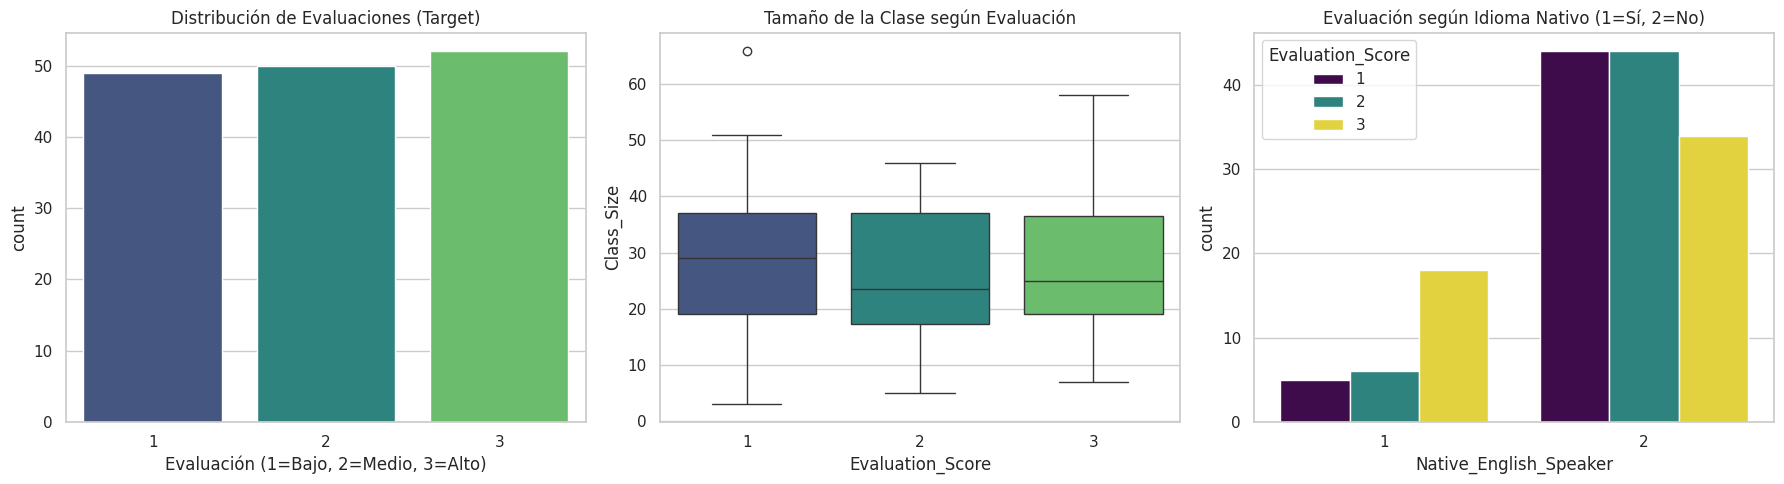

In [9]:
# Tarea A: Revisión general y Nulos
print("--- Información del Dataset ---")
df.info()
print("\nValores nulos en el dataset:\n", df.isnull().sum())

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tarea B: Distribución del Target (Balance de clases)
sns.countplot(data=df, x='Evaluation_Score', palette='viridis', ax=axes[0])
axes[0].set_title('Distribución de Evaluaciones (Target)')
axes[0].set_xlabel('Evaluación (1=Bajo, 2=Medio, 3=Alto)')

# Tarea C1: Tamaño de la clase vs Evaluación
sns.boxplot(data=df, x='Evaluation_Score', y='Class_Size', palette='viridis', ax=axes[1])
axes[1].set_title('Tamaño de la Clase según Evaluación')

# Tarea C2: Idioma Nativo vs Evaluación
sns.countplot(data=df, x='Native_English_Speaker', hue='Evaluation_Score', palette='viridis', ax=axes[2])
axes[2].set_title('Evaluación según Idioma Nativo (1=Sí, 2=No)')

plt.tight_layout()
plt.show()

## 3. Preprocesamiento e Implementación del Experimento

In [10]:
# Preprocesamiento
# 1. Separar características (X) y objetivo (y)
X = df.drop('Evaluation_Score', axis=1)
y = df['Evaluation_Score']

# 2. One-Hot Encoding a las variables nominales
X_encoded = pd.get_dummies(X, columns=['Native_English_Speaker', 'Course_Instructor', 'Course', 'Semester'], drop_first=True)

# 3. Train-Test Split (Estratificado para mantener proporciones de clases)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# 4. Escalado de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definir los modelos
modelos = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Regresion Logistica": LogisticRegression(random_state=42, max_iter=1000) # Usamos max_iter=1000 para asegurar que el modelo converja matemáticamente
}

# Entrenar y predecir
resultados = {}
predicciones = {}

for nombre, modelo in modelos.items():
    # Entrenar
    modelo.fit(X_train_scaled, y_train)
    # Predecir
    y_pred = modelo.predict(X_test_scaled)
    predicciones[nombre] = y_pred

    # Calcular métricas (usamos average='macro' por ser multiclase)
    resultados[nombre] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='macro'),
        "F1-Score": f1_score(y_test, y_pred, average='macro')
    }

print("¡Modelos entrenados con éxito!")

¡Modelos entrenados con éxito!


## 4. Presentación de Resultados

,Accuracy,Precision,Recall,F1-Score
Decision Tree,0.483871,0.487879,0.478788,0.482540
Random Forest,0.645161,0.667929,0.645455,0.648211
Regresion Logistica,0.483871,0.544872,0.484848,0.492521


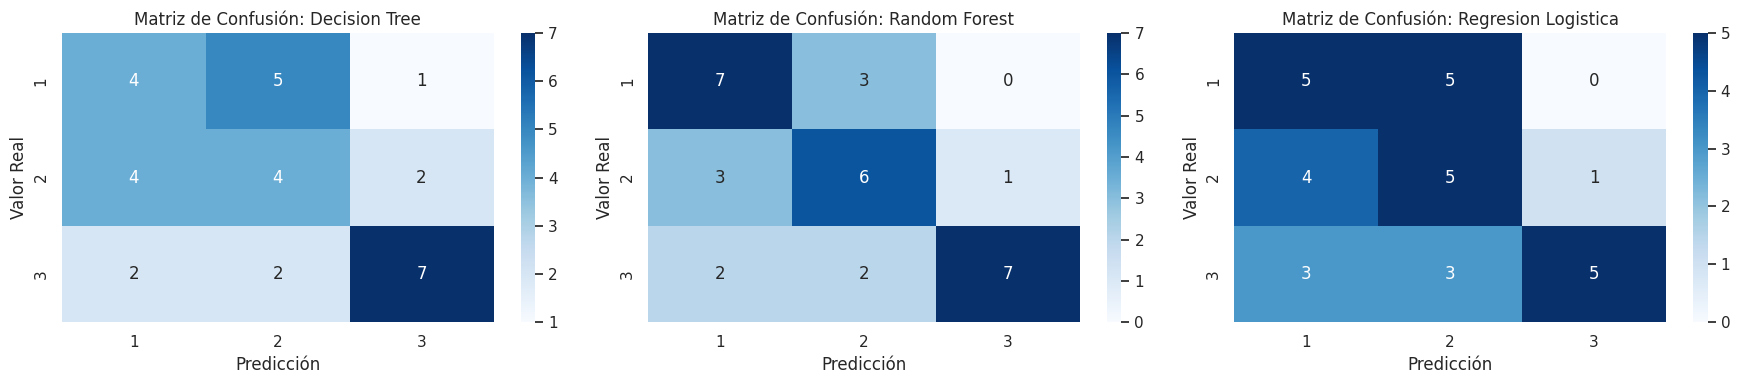

In [11]:
# Mostrar tabla de métricas
df_resultados = pd.DataFrame(resultados).T
display(df_resultados)

# Dibujar Matrices de Confusión
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, (nombre, y_pred) in enumerate(predicciones.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])
    axes[i].set_title(f'Matriz de Confusión: {nombre}')
    axes[i].set_ylabel('Valor Real')
    axes[i].set_xlabel('Predicción')

plt.tight_layout()
plt.show()

## 5. Análisis de Resultados

* **Observación de métricas:** Al observar las matrices de confusión y las métricas, el modelo Random Forest presentó el mejor desempeño global. De las 31 evaluaciones en el conjunto de prueba, logró predecir correctamente 20 (diagonal principal: 7 + 6 + 7), alcanzando una exactitud (Accuracy) aproximada del 64.5%. Superó de manera evidente al Árbol de Decisión (48.3%) y a la Regresión Logística (41.9%).
* **Análisis Exploratorio (EDA):** Nuestros gráficos iniciales revelaron que las tres clases (1=Bajo, 2=Medio, 3=Alto) estaban bastante balanceadas. Sin embargo, descubrimos que los ayudantes no nativos (2) son la inmensa mayoría, y curiosamente, los pocos ayudantes que sí son nativos en inglés tienden a recibir evaluaciones Altas (3) con mayor frecuencia.
* **Rendimiento general y dificultad:** El dataset "Teaching Assistant Evaluation" es notoriamente complejo debido a su pequeño tamaño (151 filas) y a que casi todas sus variables son identificadores categóricos. Esto hace que predecir con alta exactitud sea un gran desafío, justificando por qué los modelos rondan el 60-65% como máximo histórico general.
* **Matrices de confusión:** Al observar gráficamente los errores, notamos comportamientos muy reveladores:
    * El Random Forest es el más robusto, logrando predecir muy bien las clases extremas (7 aciertos en Baja y 7 aciertos en Alta).
    * El modelo de Regresión Logística tuvo el desempeño más bajo en este experimento. Al analizar su matriz, vemos que le cuesta establecer fronteras claras: distribuye mucho sus errores y, notablemente, de los 11 casos con evaluación Alta (clase 3), casi la mitad (5 casos) los clasificó de manera errónea como evaluación Media (clase 2).
    * El Árbol de Decisión tuvo muchos problemas con la clase 1 (Bajo), confundiendo a la mayoría de estos ayudantes con la categoría 2 (Medio).